# KGD for a Lotka–Volterra model

### Setup

We fit a well-specified Lotka–Volterra model with a particle-discretized Wasserstein gradient flow and monitor convergence with the squared Kernel Gradient Discrepancy (KGD²). The model is deliberately small—only the prey growth and interaction parameters are inferred—but its ODE likelihood has sensitive gradients over a long time horizon.

We use the biased KGD² V-statistic, which is non-negative and therefore convenient for a convergence trace. The kernel bandwidth is selected once from the initial particle cloud and held fixed throughout sampling.

In [2]:
import numba.core.serialize

# SunODE contains CFFI objects that Numba may fail to inspect for serialization.
_is_serializable = numba.core.serialize.is_serialiable


def _safe_is_serializable(obj):
    try:
        return _is_serializable(obj)
    except TypeError:
        return False


numba.core.serialize.is_serialiable = _safe_is_serializable

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import sympy as sym
from scipy.integrate import odeint
from scipy.special import expit

import pymc_prop as pro
import sunode
from sunode.wrappers.as_pytensor import solve_ivp

az.style.use("arviz-variat")

## Simulate predator–prey data

The data-generating parameters follow the two-dimensional example in which $x_1=\operatorname{logit}(\alpha)$ and $x_2=\operatorname{logit}(\beta/\alpha)$. The remaining ODE parameters and initial populations are fixed.

In [3]:
SEED = 42
TRUE_ALPHA = expit(-1.0)
TRUE_BETA = expit(-3.0)
GAMMA = 0.4
DELTA = 0.02
INITIAL_STATE = np.array([10.0, 15.0])
OBS_SIGMA = 1.0


def lotka_volterra(state, time, alpha, beta, gamma, delta):
    prey, predator = state
    return [
        alpha * prey - beta * prey * predator,
        delta * prey * predator - gamma * predator,
    ]


t_obs = np.arange(61, dtype=float)
true_states = odeint(
    lotka_volterra,
    INITIAL_STATE,
    t_obs,
    args=(TRUE_ALPHA, TRUE_BETA, GAMMA, DELTA),
)
rng = np.random.default_rng(SEED)
observed_data = true_states + rng.normal(0.0, OBS_SIGMA, true_states.shape)

t_dense = np.linspace(t_obs[0], t_obs[-1], 2_000)
true_states_dense = odeint(
    lotka_volterra,
    INITIAL_STATE,
    t_dense,
    args=(TRUE_ALPHA, TRUE_BETA, GAMMA, DELTA),
)

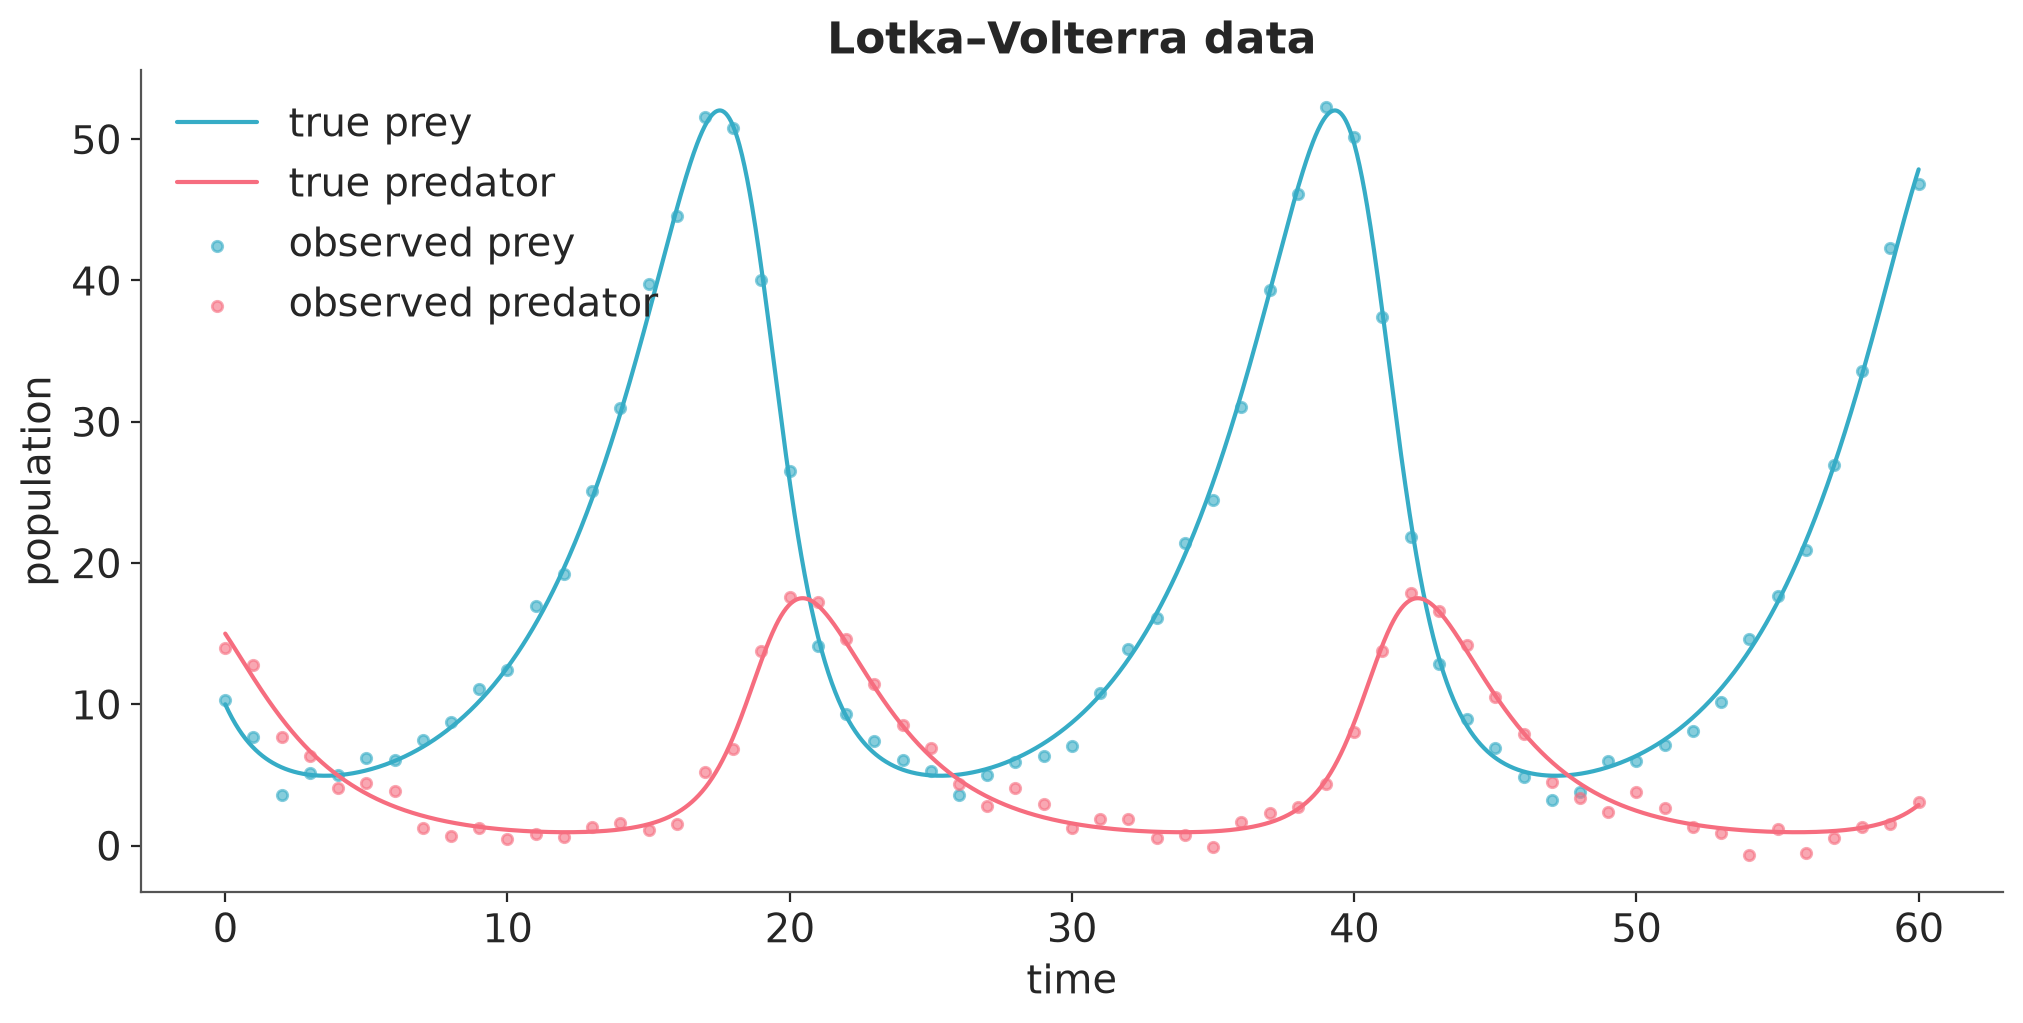

In [4]:
_, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_dense, true_states_dense[:, 0], label="true prey")
ax.plot(t_dense, true_states_dense[:, 1], label="true predator")
ax.scatter(t_obs, observed_data[:, 0], s=14, alpha=0.6, label="observed prey")
ax.scatter(t_obs, observed_data[:, 1], s=14, alpha=0.6, label="observed predator")
ax.set(title="Lotka–Volterra data", xlabel="time", ylabel="population")
ax.legend();

## PyMC model

We solve the ODE in log-population space to preserve positivity. The priors are defined directly in the unconstrained coordinates required by `sample_pro` and are centred near the data-generating values. SunODE supplies adjoint sensitivities for the likelihood gradient.

In [5]:
def lotka_volterra_log(time, state, params):
    prey = sym.exp(state.log_prey)
    predator = sym.exp(state.log_predator)
    return {
        "log_prey": params.alpha - params.beta * predator,
        "log_predator": params.delta * prey - params.gamma,
    }


with pm.Model() as model:
    x1 = pm.Normal("x1", mu=-1.0, sigma=0.1)
    x2 = pm.Normal("x2", mu=-1.5, sigma=0.1)

    alpha = pm.Deterministic("alpha", pt.sigmoid(x1))
    beta = pm.Deterministic("beta", alpha * pt.sigmoid(x2))

    solution, _, problem, solver, _, _ = solve_ivp(
        y0={
            "log_prey": np.asarray(np.log(INITIAL_STATE[0])),
            "log_predator": np.asarray(np.log(INITIAL_STATE[1])),
        },
        params={
            "alpha": (alpha, ()),
            "beta": (beta, ()),
            "gamma": np.asarray(GAMMA),
            "delta": np.asarray(DELTA),
        },
        rhs=lotka_volterra_log,
        tvals=t_obs,
        t0=float(t_obs[0]),
    )

    cvodes = sunode._cvodes.lib
    cvodes.CVodeSetMaxNumSteps(solver._ode, 5_000)
    cvodes.CVodeSetMaxNumStepsB(solver._ode, solver._odeB, 5_000)

    prey_mu = pm.Deterministic("prey_mu", pt.exp(solution["log_prey"]))
    predator_mu = pm.Deterministic(
        "predator_mu", pt.exp(solution["log_predator"])
    )

    pm.Normal("prey_obs", mu=prey_mu, sigma=OBS_SIGMA, observed=observed_data[:, 0])
    pm.Normal(
        "predator_obs",
        mu=predator_mu,
        sigma=OBS_SIGMA,
        observed=observed_data[:, 1],
    )

### Run the sampler

Every simulation step is retained so that KGD² and the particle trajectories share the same `draw` and `step` coordinates. The conservative FUSE floor avoids a large first update caused by the sensitive initial ODE gradients. KGD² uses the score evaluated at each post-update particle cloud; that gradient is cached for the following timestep.

In [9]:
dt = pro.sample_pro(
    model=model,
    n_particles=10,
    n_steps=40,
    tune=0,
    step_size=1e-8,
    r_eps=1e-10,
    kgd_interval=1,
    biased=False,
    random_seed=46,
)

/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run SolveODEAdjoint{_solver_id=272591093028416}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SolveODEAdjoint should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SolveODEAdjoint should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node

## ArviZ DataTree output

`draw` indexes retained WGF updates, `step` records the simulation step, and `chain` indexes particles rather than independent MCMC chains. Consequently, MCMC diagnostics such as R-hat and ESS are not meaningful here. KGD² and FUSE quantities are step-level statistics broadcast over `chain` for the ArviZ layout.

In [6]:
dt

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 20, chain: 20)
│       Coordinates:
│         * draw     (draw) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
│           step     (draw) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
│         * chain    (chain) int64 160B 0 1 2 3 4 5 6 7 8 ... 11 12 13 14 15 16 17 18 19
│       Data variables:
│           x1       (draw, chain) float64 3kB -0.7465 -0.927 -1.13 ... -0.9572 -0.984
│           x2       (draw, chain) float64 3kB -1.662 -1.465 -1.524 ... -1.457 -1.559
│       Attributes:
│           created_at:                 2026-08-10T18:18:41.193068+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:             (prey_obs_dim_0: 61, predator_obs_dim_0: 61)
│       Coordinates:
│         * prey_obs_dim_0      (prey_obs_dim_0) int64 488B 0 1 2 3 4 ... 56 57 58 59 60
│         * predator_obs_dim_0  (predator_obs_dim_0) int64 488B 0 1 2 3 ... 57 58 59 60
│       Data variables:
│           prey_obs            (prey_obs_dim_0) float64 488B 10.3 7.669 ... 42.29 46.83
│           predator_obs        (predator_obs_dim_0) float64 488B 13.96 12.8 ... 3.057
│       Attributes:
│           created_at:                 2026-08-10T18:18:41.200633+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:             (draw: 20, chain: 20, prey_obs_dim_0: 61,
│                                predator_obs_dim_0: 61)
│       Coordinates:
│         * draw                (draw) int64 160B 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
│           step                (draw) int64 160B 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
│         * chain               (chain) int64 160B 0 1 2 3 4 5 6 ... 14 15 16 17 18 19
│         * prey_obs_dim_0      (prey_obs_dim_0) int64 488B 0 1 2 3 4 ... 56 57 58 59 60
│         * predator_obs_dim_0  (predator_obs_dim_0) int64 488B 0 1 2 3 ... 57 58 59 60
│       Data variables:
│           prey_obs            (draw, chain, prey_obs_dim_0) float64 195kB -0.9654 ....
│           predator_obs        (draw, chain, predator_obs_dim_0) float64 195kB -1.46...
│       Attributes:
│           created_at:                 2026-08-10T18:18:41.193068+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /sample_stats
│       Dimensions:                       (draw: 20, chain: 20)
│       Coordinates:
│         * draw                          (draw) int64 160B 0 1 2 3 4 ... 15 16 17 18 19
│           step                          (draw) int64 160B 0 1 2 3 4 ... 15 16 17 18 19
│         * chain                         (chain) int64 160B 0 1 2 3 4 ... 16 17 18 19
│       Data variables:
│           particle_spread               (draw, chain) float64 3kB 0.1034 ... 0.1034
│           learning_rate                 (draw, chain) float64 3kB 1.0 1.0 ... 1.0 1.0
│           x1_spread                     (draw, chain) float64 3kB 0.1358 ... 0.1357
│           x2_spread                     (draw, chain) float64 3kB 0.07101 ... 0.07117
│           mean_log_score                (draw, chain) float64 3kB -2.784e+03 ... -2...
│           se_log_score                  (draw, chain) float64 3kB 674.9 ... 675.2
│           fuse_gradient_energy          (draw, chain) float64 3kB 6.73e+13 ... 4.93...
│           fuse_half_step_distance_sq    (draw, chai

## Flow diagnostics

The biased KGD² trace is non-negative. FUSE records the step size used for each update, the incremental gradient energy, and the squared half-step distance. Since these values are identical across particles, we select one `chain` before plotting.

KeyError: 'Could not find node at fuse_step_size'

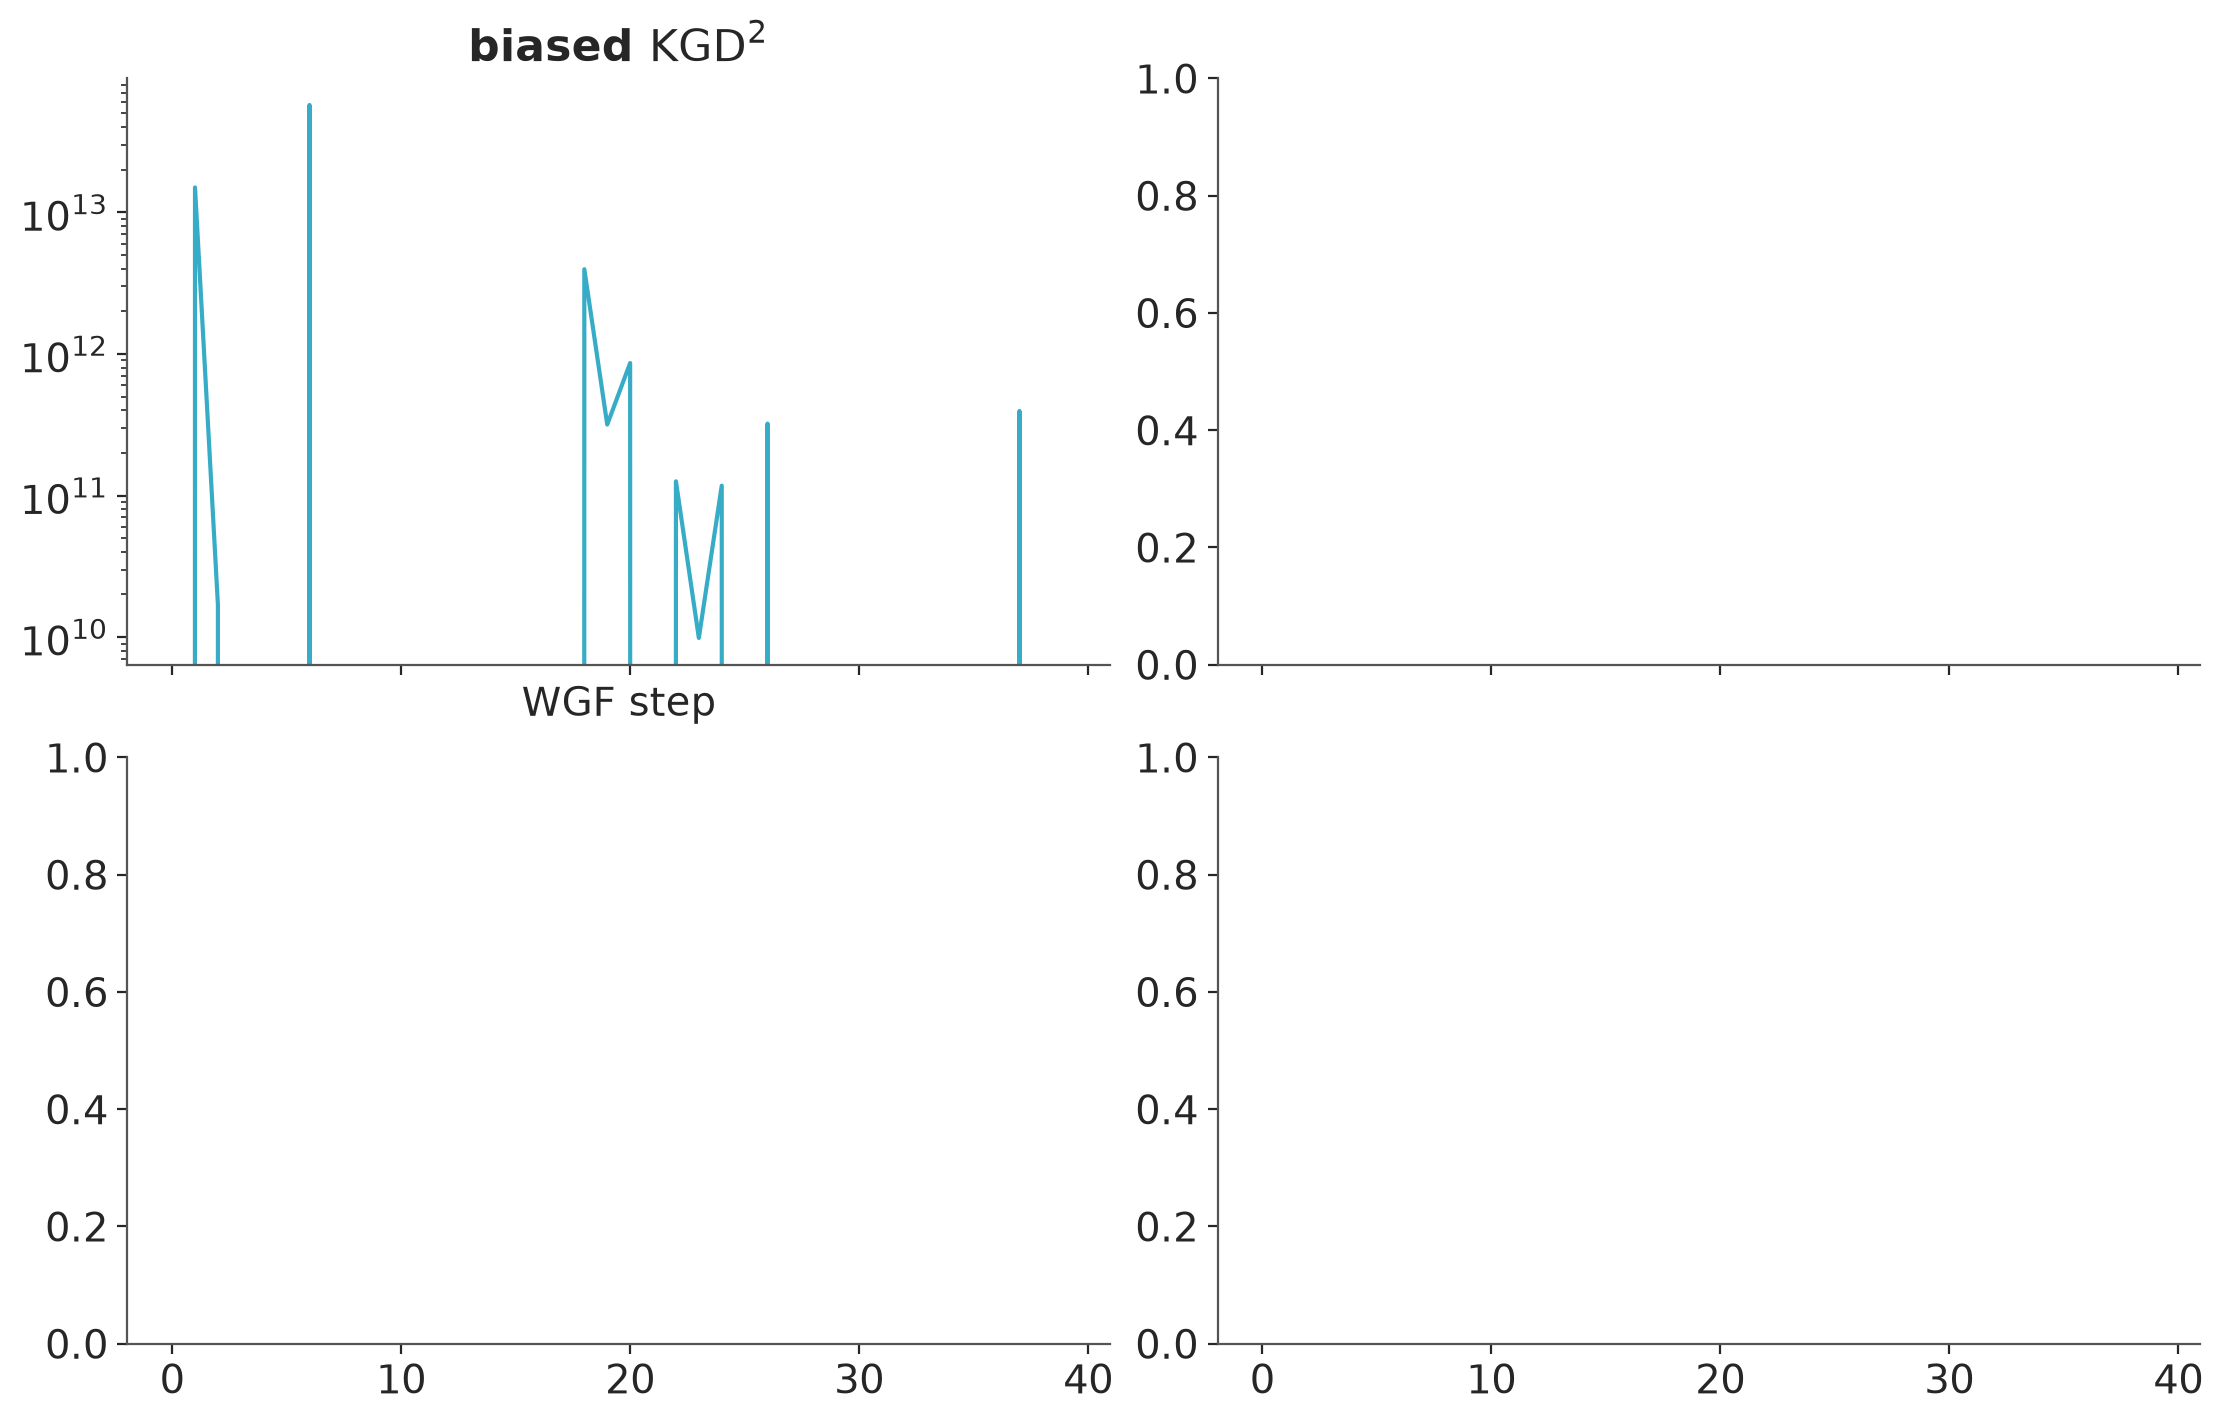

In [10]:
stats = dt.sample_stats.isel(chain=0)
diagnostics = [
    ("kgd_squared", r"biased $\mathrm{KGD}^2$"),
    ("fuse_step_size", "FUSE step size"),
    ("fuse_gradient_energy", "gradient energy"),
    ("fuse_half_step_distance_sq", "half-step distance squared"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (name, title) in zip(axes.flat, diagnostics, strict=True):
    ax.plot(stats.step, stats[name])
    ax.set(title=title, xlabel="WGF step")
    ax.set_yscale("log")
fig.suptitle("WGF convergence diagnostics")
fig.tight_layout();

## Particle trajectories

The open markers show the first post-update cloud and the filled markers show the final cloud. The cross marks the data-generating parameter.

/tmp/ipykernel_226485/2713126720.py:69: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


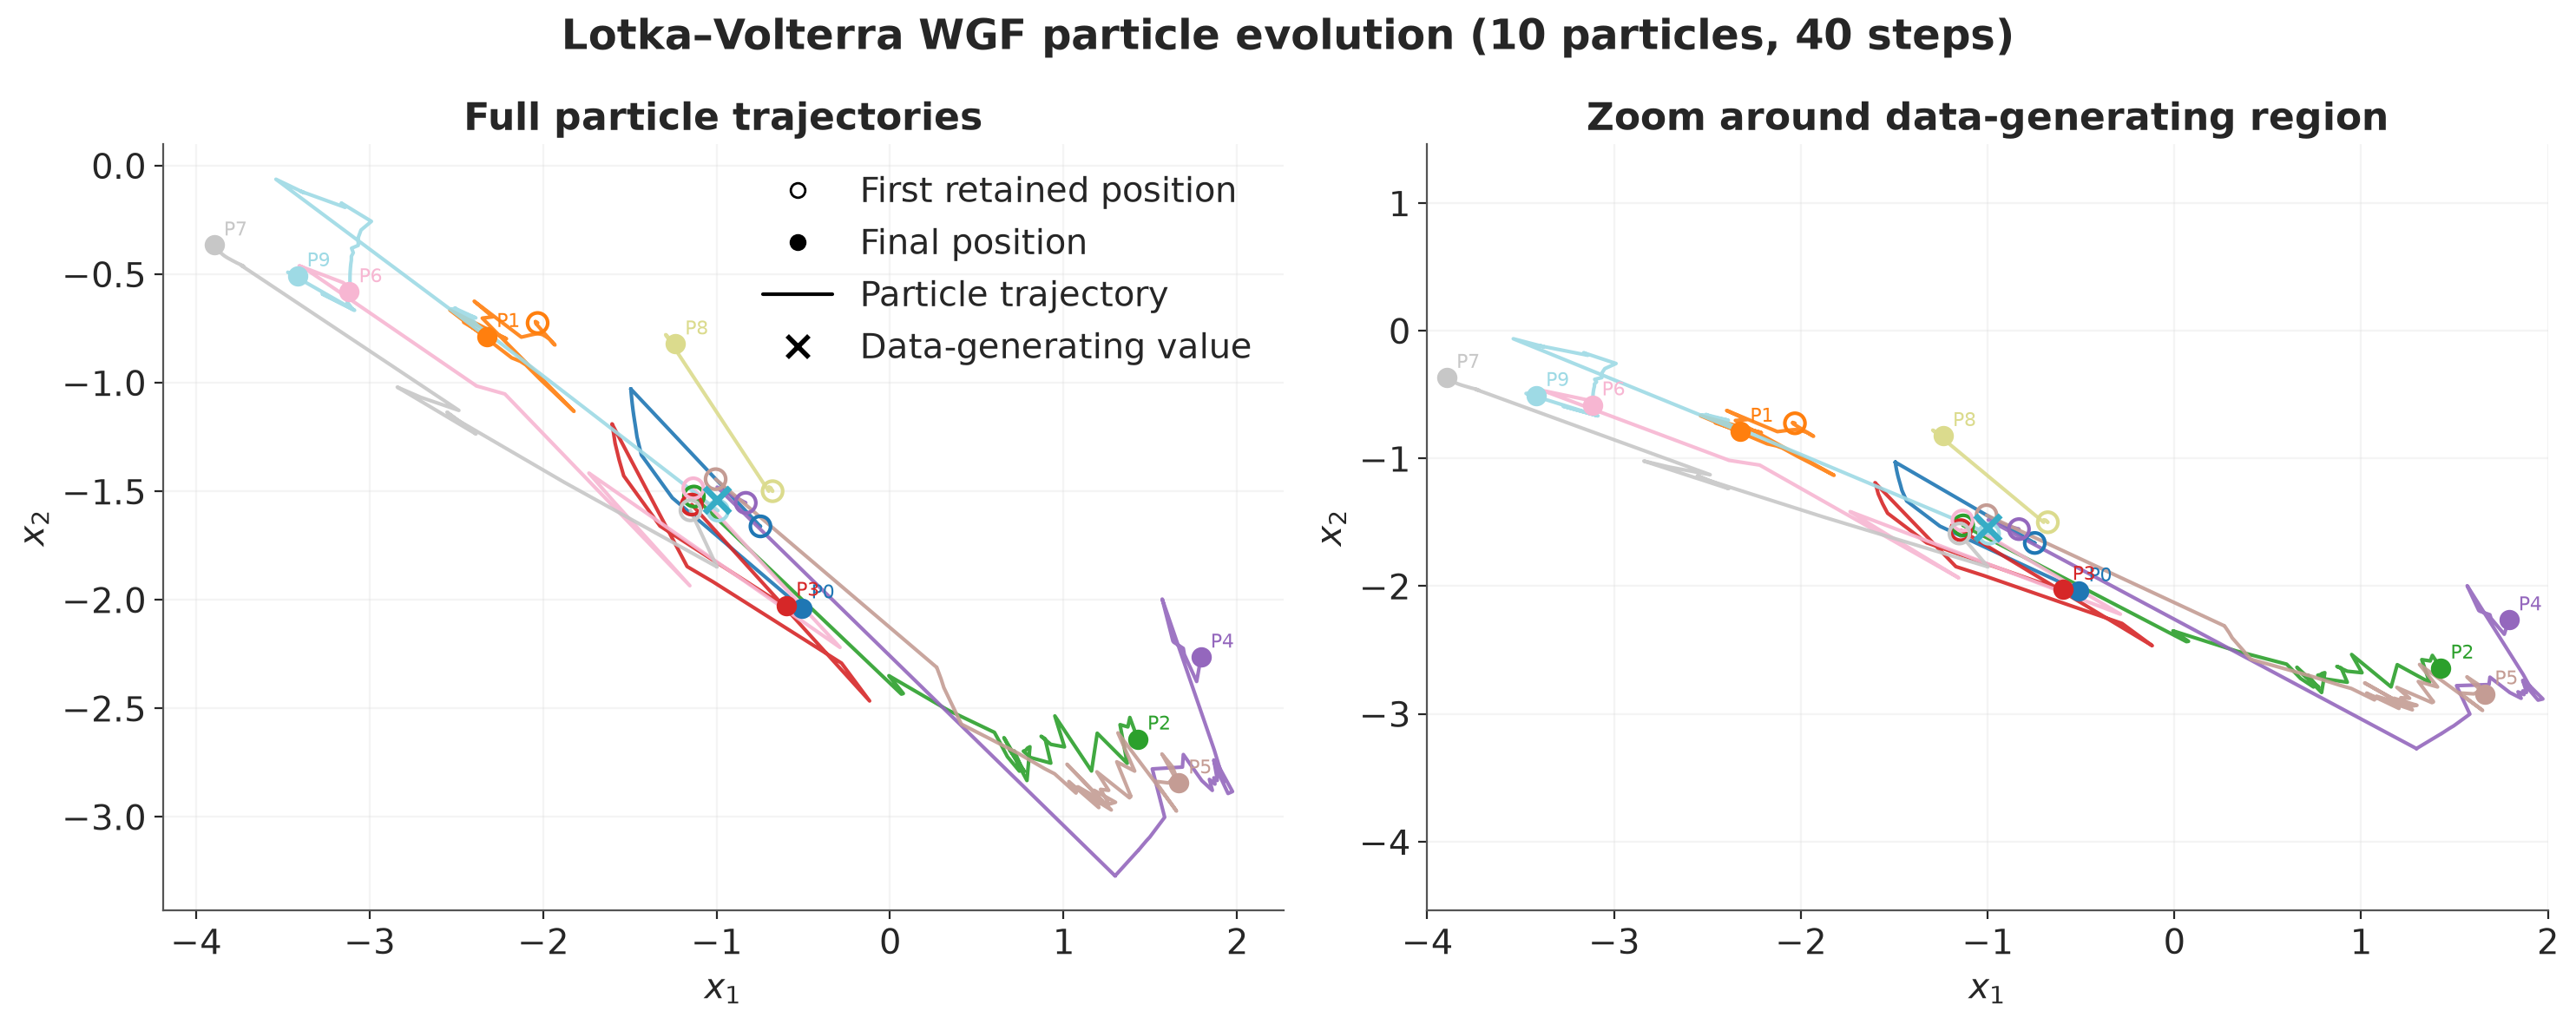

In [11]:
true_x1 = np.log(TRUE_ALPHA / (1.0 - TRUE_ALPHA))
true_ratio = TRUE_BETA / TRUE_ALPHA
true_x2 = np.log(true_ratio / (1.0 - true_ratio))

x1_paths = dt.posterior["x1"].transpose("chain", "draw").values
x2_paths = dt.posterior["x2"].transpose("chain", "draw").values

n_particles, n_retained = x1_paths.shape
colors = plt.cm.tab20(np.linspace(0, 1, n_particles))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Lotka–Volterra WGF particle evolution "
    f"({n_particles} particles, {n_retained} steps)"
)

for ax in axes:
    for particle, color in enumerate(colors):
        ax.plot(
            x1_paths[particle],
            x2_paths[particle],
            color=color,
            linewidth=1.5,
            alpha=0.9,
        )
        ax.scatter(
            x1_paths[particle, 0],
            x2_paths[particle, 0],
            s=70,
            facecolors="none",
            edgecolors=color,
            linewidths=1.5,
            zorder=3,
        )
        ax.scatter(
            x1_paths[particle, -1],
            x2_paths[particle, -1],
            s=55,
            color=color,
            zorder=4,
        )
        ax.annotate(
            f"P{particle}",
            (x1_paths[particle, -1], x2_paths[particle, -1]),
            xytext=(4, 4),
            textcoords="offset points",
            color=color,
            fontsize=8,
        )

    ax.scatter(true_x1, true_x2, marker="x", s=110, color="C0", linewidths=2.5, zorder=5)
    ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$")
    ax.grid(alpha=0.2)

axes[0].set_title("Full particle trajectories")
axes[1].set(
    title="Zoom around data-generating region",
    xlim=(true_x1 - 3, true_x1 + 3),
    ylim=(true_x2 - 3, true_x2 + 3),
)

legend_handles = [
    plt.Line2D([], [], marker="o", linestyle="none", markerfacecolor="none", markeredgecolor="black", label="First retained position"),
    plt.Line2D([], [], marker="o", linestyle="none", color="black", label="Final position"),
    plt.Line2D([], [], color="black", label="Particle trajectory"),
    plt.Line2D([], [], marker="x", linestyle="none", color="black", markersize=9, markeredgewidth=2, label="Data-generating value"),
]
axes[0].legend(handles=legend_handles, loc="best")
fig.tight_layout();

## Final particle trajectories in observation space

Finally, we solve the noiseless ODE at each particle in the final cloud. The ribbons summarize variation across the particle approximation; they are not observation-noise predictive intervals.

In [12]:
trajectory_fn = model.compile_fn(
    inputs=model.value_vars,
    outs=[model["prey_mu"], model["predator_mu"]],
    point_fn=True,
    on_unused_input="ignore",
)
final_cloud = dt.posterior.isel(draw=-1)
points = zip(final_cloud["x1"].values, final_cloud["x2"].values, strict=True)
trajectories = [
    trajectory_fn({"x1": np.asarray(x1), "x2": np.asarray(x2)})
    for x1, x2 in points
]
prey_paths = np.stack([np.asarray(prey).squeeze() for prey, _ in trajectories])
predator_paths = np.stack(
    [np.asarray(predator).squeeze() for _, predator in trajectories]
)

/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run SolveODEAdjoint{_solver_id=272591093028416}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


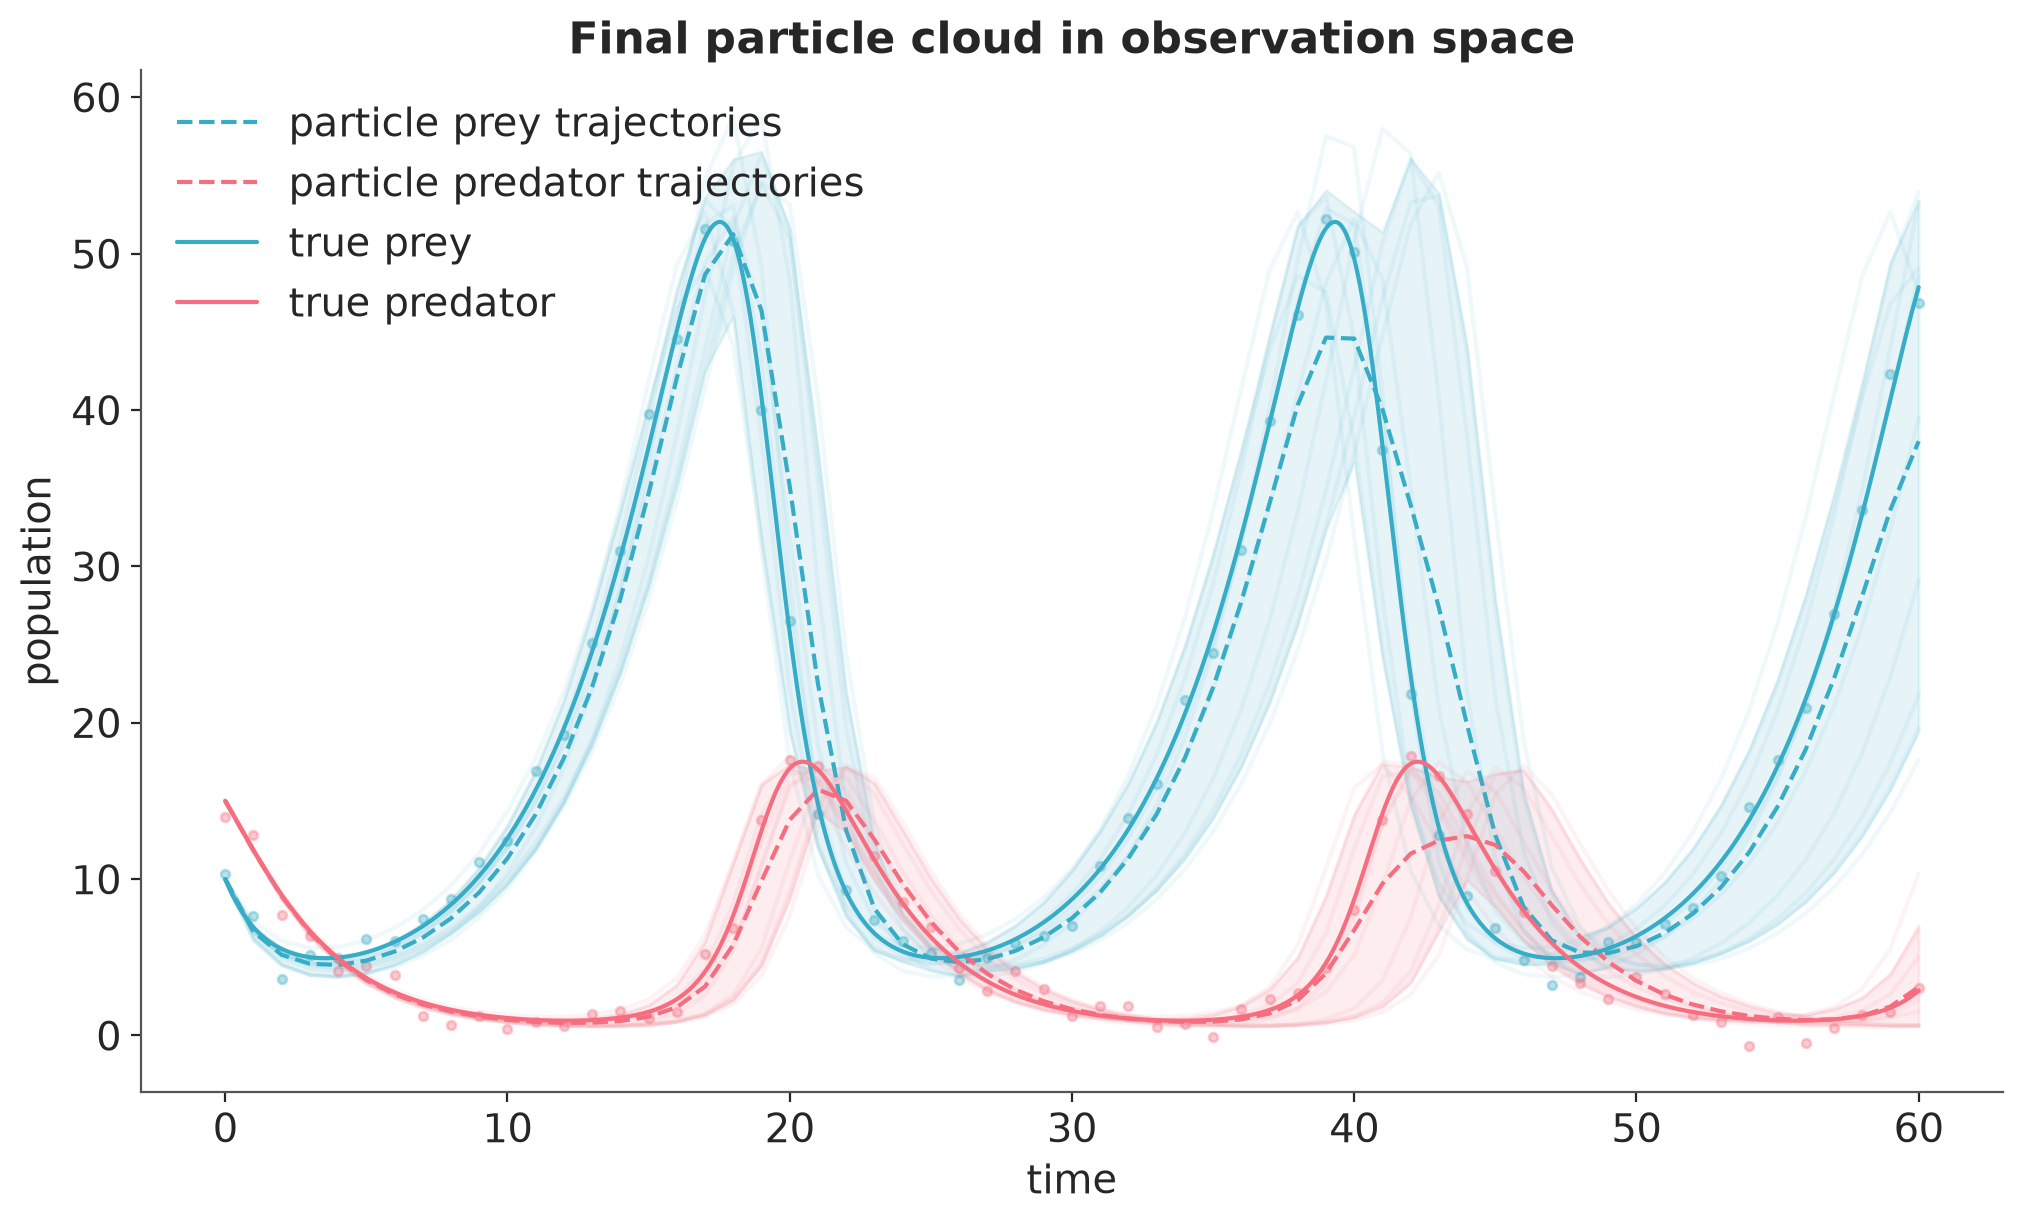

In [25]:
_, ax = plt.subplots(figsize=(10, 6))
for paths, color, label in [
    (prey_paths, "C0", "particle prey trajectories"),
    (predator_paths, "C1", "particle predator trajectories"),
]:
    lower, upper = np.quantile(paths, [0.1, 0.9], axis=0)
    ax.plot(t_obs, paths.T, color=color, alpha=0.08)
    ax.plot(t_obs, paths.mean(axis=0), color=color, linestyle="--", label=label)
    ax.fill_between(t_obs, lower, upper, color=color, alpha=0.12)

ax.plot(t_dense, true_states_dense[:, 0], color="C0", label="true prey")
ax.plot(t_dense, true_states_dense[:, 1], color="C1", label="true predator")
ax.scatter(t_obs, observed_data[:, 0], s=10, color="C0", alpha=0.35)
ax.scatter(t_obs, observed_data[:, 1], s=10, color="C1", alpha=0.35)
ax.set(
    title="Final particle cloud in observation space",
    xlabel="time",
    ylabel="population",
)
ax.legend();